In [6]:
import os
import cv2
import imagehash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

plt.style.use("ggplot")

In [7]:
DATASET_PATH = r"E:\SIH\DATASET\IMAGES"

image_paths = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")):
            image_paths.append(os.path.join(root,file))

print(f"Total Images : {len(image_paths)}")

Total Images : 437


In [8]:
records = []

for path in tqdm(image_paths):

    img = cv2.imread(path)

    if img is None:
        continue

    h,w = img.shape[:2]

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)

    blur = cv2.Laplacian(gray,cv2.CV_64F).var()

    size = os.path.getsize(path)/1024

    records.append({

        "filename":os.path.basename(path),

        "width":w,

        "height":h,

        "resolution":w*h,

        "brightness":brightness,

        "blur":blur,

        "filesize_kb":size,

        "format":path.split(".")[-1].lower()

    })

df = pd.DataFrame(records)

df.head()

100%|██████████| 437/437 [00:12<00:00, 36.21it/s]


,filename,width,height,resolution,brightness,blur,filesize_kb,format
0,images01.jpg,225,225,50625,216.982202,2432.560158,6.761719,jpg
1,images02.jpg,225,224,50400,204.100159,2380.460064,6.478516,jpg
2,images03.jpg,225,225,50625,165.790499,1962.472052,8.363281,jpg
3,images04.jpg,225,225,50625,220.155891,1708.755784,5.142578,jpg
4,images05.jpg,200,200,40000,223.409525,321.940650,3.845703,jpg


In [9]:
print("="*50)

print("Dataset Summary")

print("="*50)

print(df.describe())

print("\nFormats\n")

print(df["format"].value_counts())

Dataset Summary
            width      height    resolution  brightness          blur  \
count  437.000000  437.000000    437.000000  437.000000    437.000000   
mean   204.713959  200.858124  42974.983982  196.471406   2897.944693   
std     54.155215   52.971024  15615.597507   32.332262   2433.076200   
min    100.000000  100.000000  10000.000000   57.120232    171.677156   
25%    198.000000  183.000000  50246.000000  177.359255   1388.510635   
50%    225.000000  225.000000  50430.000000  201.811800   2203.405036   
75%    225.000000  225.000000  50625.000000  221.864375   3499.570015   
max    312.000000  383.000000  50625.000000  247.703072  17551.159679   

       filesize_kb  
count   437.000000  
mean      6.256279  
std       2.980030  
min       1.149414  
25%       4.338867  
50%       6.204102  
75%       7.775391  
max      15.814453  

Formats

format
jpg    437
Name: count, dtype: int64


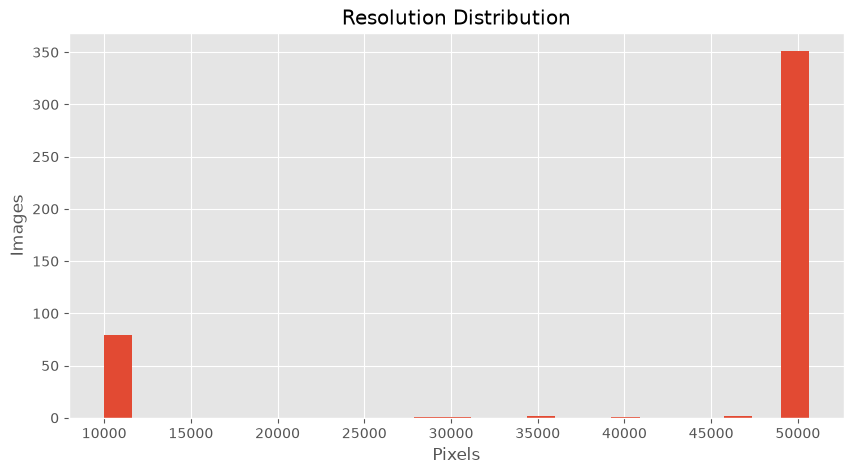

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["resolution"],bins=25)

plt.title("Resolution Distribution")

plt.xlabel("Pixels")

plt.ylabel("Images")

plt.show()

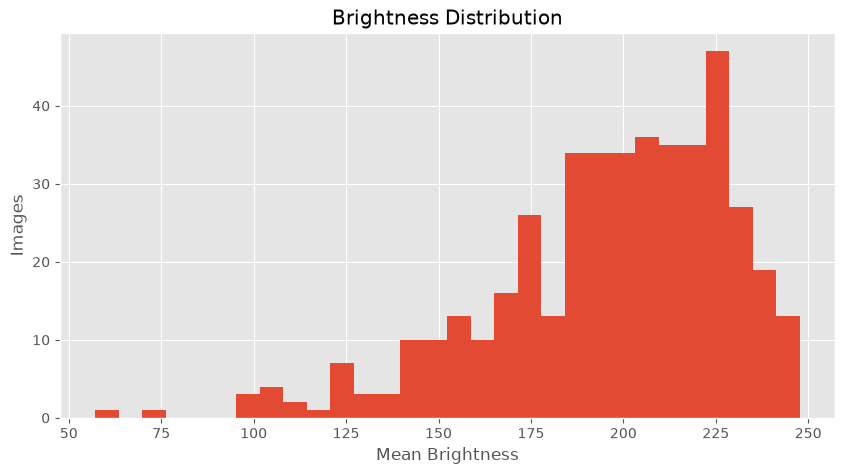

In [11]:
plt.figure(figsize=(10,5))

plt.hist(df["brightness"],bins=30)

plt.title("Brightness Distribution")

plt.xlabel("Mean Brightness")

plt.ylabel("Images")

plt.show()

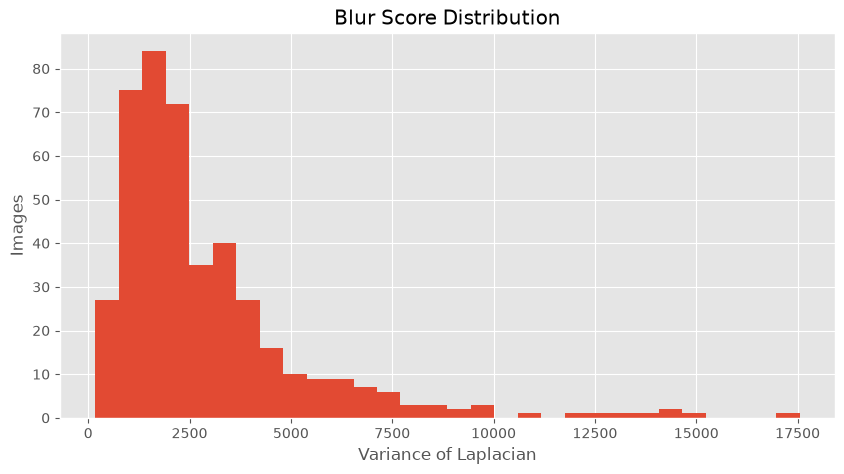

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df["blur"],bins=30)

plt.title("Blur Score Distribution")

plt.xlabel("Variance of Laplacian")

plt.ylabel("Images")

plt.show()

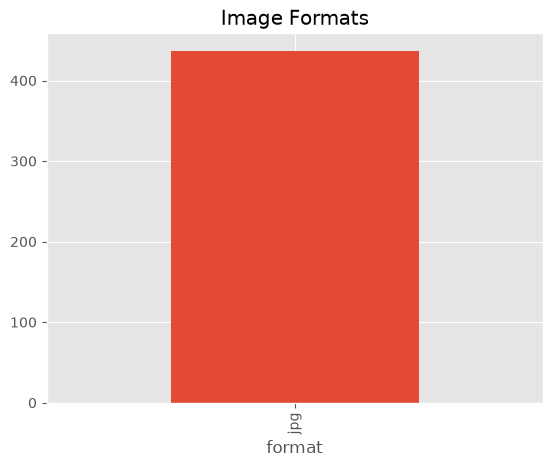

In [13]:
df["format"].value_counts().plot(kind="bar")

plt.title("Image Formats")

plt.show()

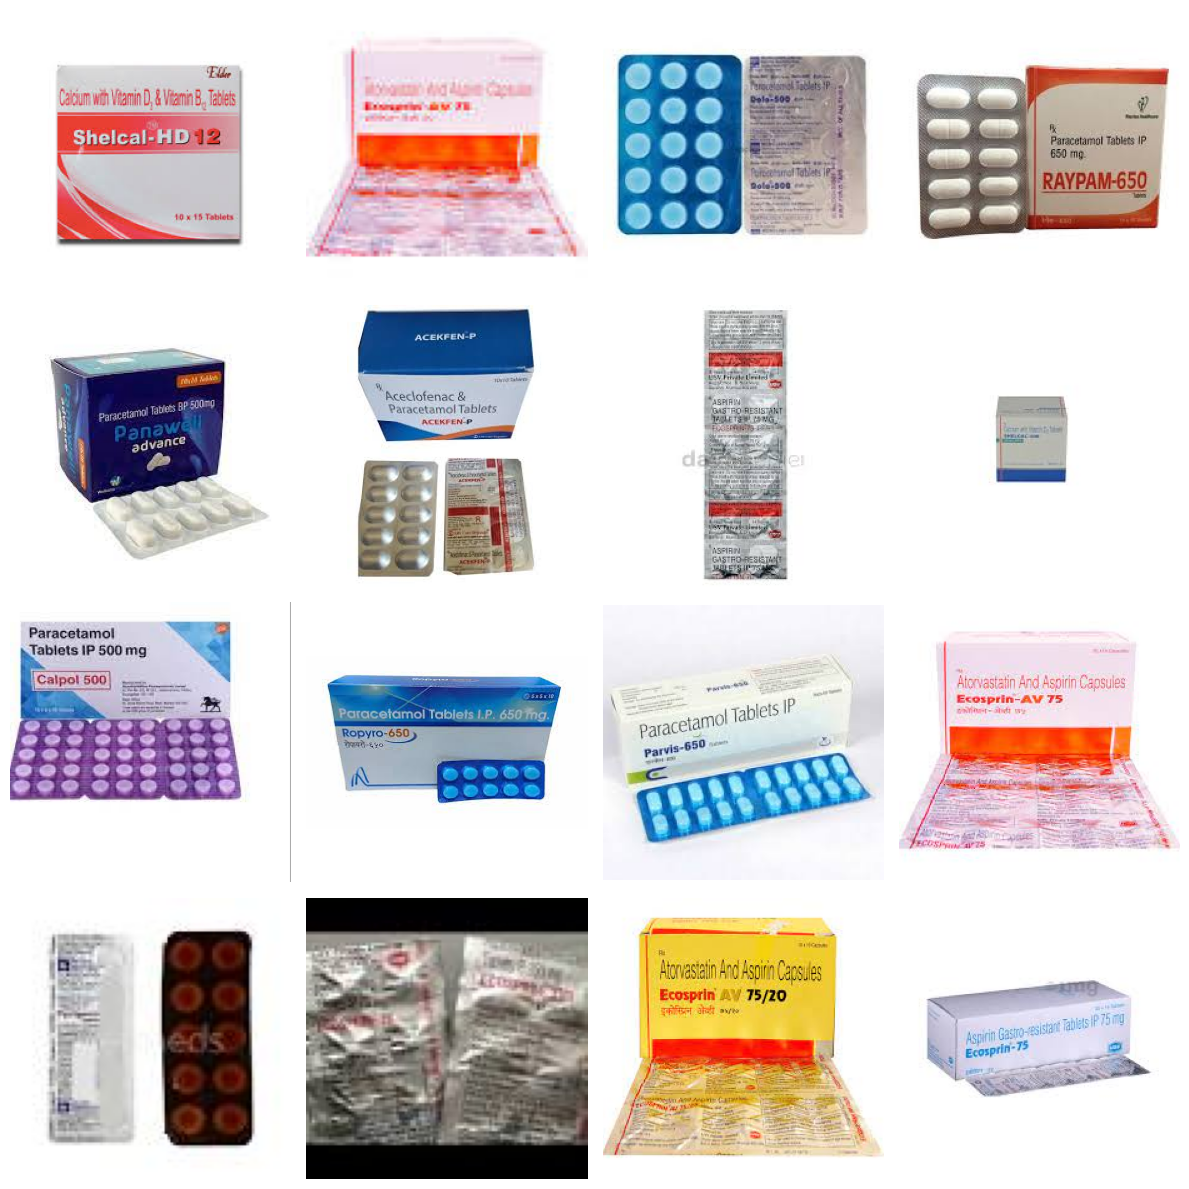

In [14]:
sample = df.sample(16)

plt.figure(figsize=(12,12))

for i,row in enumerate(sample.itertuples()):

    img = cv2.imread(os.path.join(DATASET_PATH,row.filename))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
hashes = {}

duplicates = []

for path in tqdm(image_paths):

    h = imagehash.phash(Image.open(path))

    if h in hashes:

        duplicates.append(path)

    else:

        hashes[h]=path

print("Duplicate Images :",len(duplicates))

100%|██████████| 437/437 [00:20<00:00, 20.94it/s]

Duplicate Images : 39


In [16]:
low_blur = df[df["blur"]<100]

print("Low Blur Images")

display(low_blur.head())

Low Blur Images


,filename,width,height,resolution,brightness,blur,filesize_kb,format


In [17]:
df.to_csv("dataset_report.csv",index=False)

print("Saved dataset_report.csv")

Saved dataset_report.csv


In [18]:
print("="*60)

print("FINAL DATASET REPORT")

print("="*60)

print(f"Images : {len(df)}")

print(f"Average Width : {df.width.mean():.2f}")

print(f"Average Height : {df.height.mean():.2f}")

print(f"Average Brightness : {df.brightness.mean():.2f}")

print(f"Average Blur Score : {df.blur.mean():.2f}")

print(f"Duplicate Images : {len(duplicates)}")

print("="*60)

FINAL DATASET REPORT
Images : 437
Average Width : 204.71
Average Height : 200.86
Average Brightness : 196.47
Average Blur Score : 2897.94
Duplicate Images : 39
